# nuScenes Mini Dataset Exploration
This notebook provides a practical, visual overview of the nuScenes mini dataset to onboard new contributors. We load synchronized camera and radar data, inspect calibration metadata, and summarize annotations.

## Imports and dataset loading
We start by importing plotting utilities and our loader helpers to ensure all dataset access goes through the project API.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "scripts").exists():
            return parent
    raise RuntimeError("Could not locate project root with scripts/")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import CAMERA_CHANNEL, RADAR_CHANNEL
from scripts.data_loader import get_camera_data, get_radar_data, load_nuscenes

nusc = load_nuscenes()
plt.rcParams["figure.figsize"] = (8, 6)

## Dataset overview
We summarize the number of scenes, samples per scene, and the sensor channels available in the dataset to build intuition about scale and modalities.

In [2]:
scene_counts = [(scene["name"], scene["nbr_samples"]) for scene in nusc.scene]
channels = sorted({sensor["channel"] for sensor in nusc.sensor})

print(f"Number of scenes: {len(nusc.scene)}")
print("Samples per scene:")
for name, count in scene_counts:
    print(f"  {name}: {count}")
print("")
print("Available sensor channels:")
print(channels)

Number of scenes: 10
Samples per scene:
  scene-0061: 39
  scene-0103: 40
  scene-0553: 41
  scene-0655: 41
  scene-0757: 41
  scene-0796: 40
  scene-0916: 41
  scene-1077: 41
  scene-1094: 40
  scene-1100: 40

Available sensor channels:
['CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT', 'CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT', 'LIDAR_TOP', 'RADAR_BACK_LEFT', 'RADAR_BACK_RIGHT', 'RADAR_FRONT', 'RADAR_FRONT_LEFT', 'RADAR_FRONT_RIGHT']


## Pick one scene
We load the first scene and its first sample to inspect the core records used throughout the fusion pipeline.

In [3]:
scene = nusc.scene[0]
sample = nusc.get("sample", scene["first_sample_token"])

print(f"Scene: {scene['name']}")
print(scene["description"])
print(f"Log token: {scene['log_token']}")
print(f"Sample token: {sample['token']}")

Scene: scene-0061
Parked truck, construction, intersection, turn left, following a van
Log token: 7e25a2c8ea1f41c5b0da1e69ecfa71a2
Sample token: ca9a282c9e77460f8360f564131a8af5


## Visualize CAM_FRONT
We render the front camera image to see what the vehicle observed at the selected timestamp.

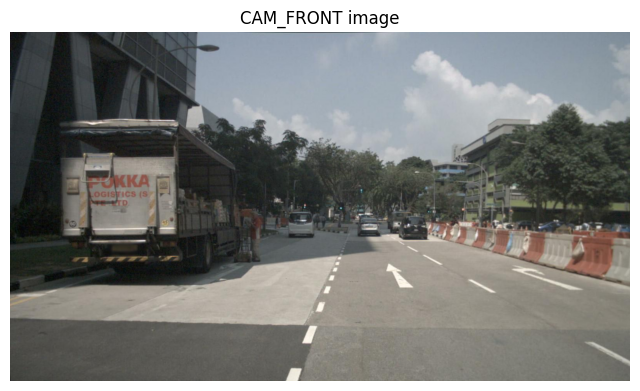

In [4]:
image_path, camera_calib = get_camera_data(nusc, sample)
image = plt.imread(str(image_path))

plt.imshow(image)
plt.title(f"{CAMERA_CHANNEL} image")
plt.axis("off")
plt.show()

## Visualize RADAR_FRONT point cloud
We project the radar point cloud into a simple bird's-eye view to see the spatial distribution of detections.

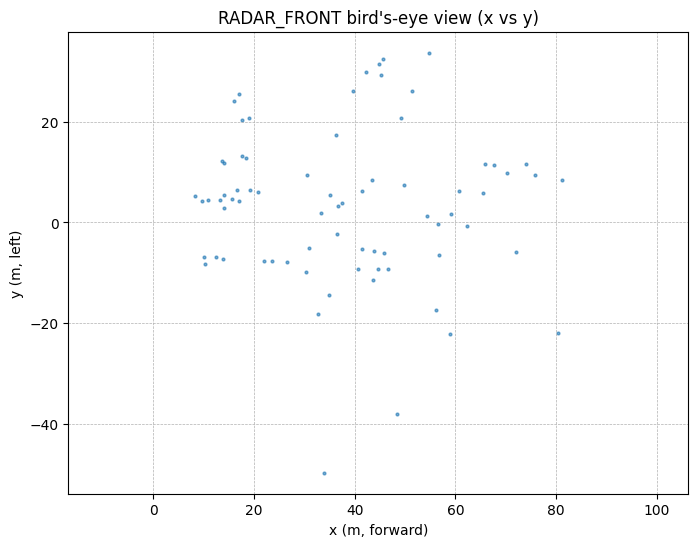

In [5]:
radar_points, radar_calib = get_radar_data(nusc, sample)
points = radar_points.points

plt.scatter(points[0], points[1], s=4, alpha=0.6)
plt.title(f"{RADAR_CHANNEL} bird's-eye view (x vs y)")
plt.xlabel("x (m, forward)")
plt.ylabel("y (m, left)")
plt.axis("equal")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## Inspect calibration data
We print the camera intrinsics (projection matrix) and the radar-to-ego transform (rotation + translation) to understand how sensors relate to the vehicle frame.

In [6]:
camera_intrinsics = np.array(camera_calib["camera_intrinsic"])
radar_translation = np.array(radar_calib["translation"])
radar_rotation = np.array(radar_calib["rotation"])

print("Camera intrinsics:")
print(camera_intrinsics)
print("")
print("Radar translation (sensor -> ego, meters):")
print(radar_translation)
print("")
print("Radar rotation (quaternion, sensor -> ego):")
print(radar_rotation)

Camera intrinsics:
[[1.26641720e+03 0.00000000e+00 8.16267020e+02]
 [0.00000000e+00 1.26641720e+03 4.91507066e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Radar translation (sensor -> ego, meters):
[3.412 0.    0.5  ]

Radar rotation (quaternion, sensor -> ego):
[0.99999848 0.         0.         0.00174533]


## Annotation overview
We count annotation categories for the selected sample to see the object distribution and plot them as a bar chart.

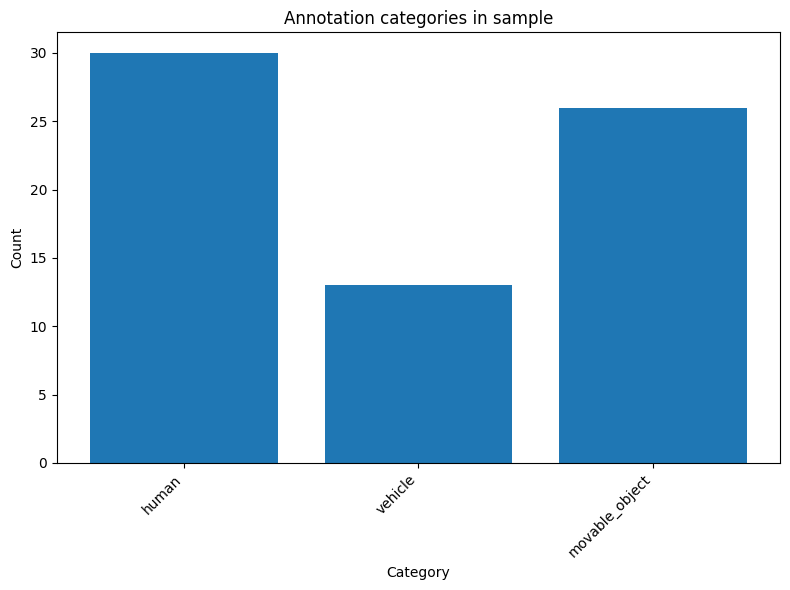

In [7]:
categories = []
for ann_token in sample["anns"]:
    ann = nusc.get("sample_annotation", ann_token)
    categories.append(ann["category_name"].split(".")[0])

counts = Counter(categories)
labels = list(counts.keys())
values = [counts[label] for label in labels]

plt.bar(labels, values)
plt.title("Annotation categories in sample")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Summary
- nuScenes mini contains multiple scenes, each with a fixed number of samples and synchronized multi-sensor data.
- Samples link camera imagery, radar point clouds, and annotations via shared tokens.
- Calibration metadata provides the transforms needed for sensor fusion and projection.
- Radar detections are sparse but informative for vehicle-centric spatial reasoning.